# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data

In [2]:
df = pd.read_csv("Ecommerce Customers.csv")

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
# Missing values check
print(df.isnull().sum())

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [5]:
df.drop(columns=["Email", "Address"], inplace=True)

In [6]:
X = df.drop(columns=["Yearly Amount Spent"])
y = df["Yearly Amount Spent"]

In [7]:
Q1 = df["Length of Membership"].quantile(0.25)
Q3 = df["Length of Membership"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Length of Membership"] >= lower) & (df["Length of Membership"] <= upper)]

In [9]:
df["App_Web_Ratio"] = df["Time on App"] / (df["Time on Website"] + 1e-6)
df["Total_Time"] = df["Time on App"] + df["Time on Website"]
df["App_Membership"] = df["Time on App"] * df["Length of Membership"]
df["Session_Membership"] = df["Avg. Session Length"] * df["Length of Membership"]

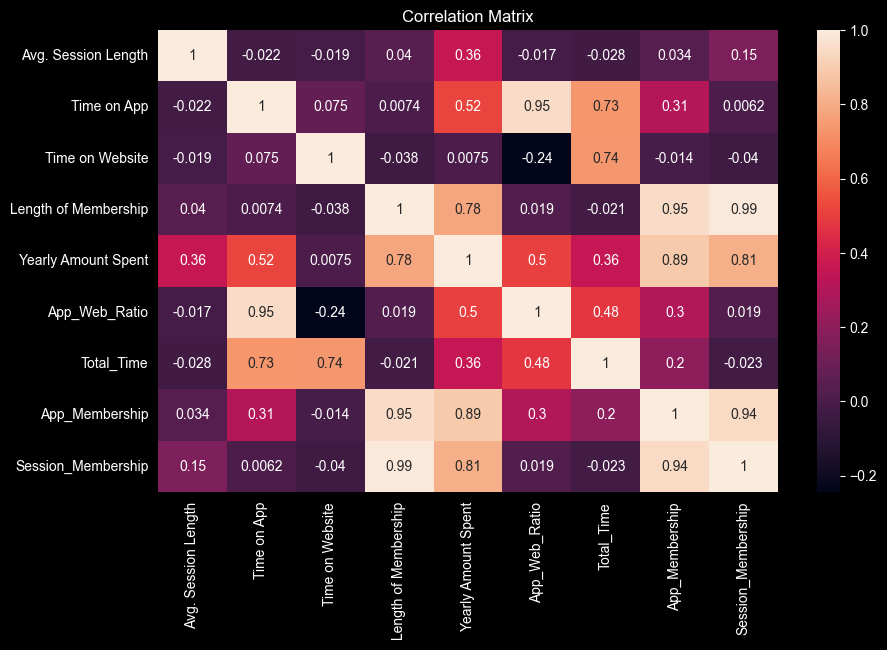

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()